# Phase 1 — Constitution du corpus et analyse acoustique exploratoire

## 0. Dépendances

In [ ]:
# !pip install librosa matplotlib numpy scipy pandas soundfile

## 1. Imports et paramètres

In [16]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import librosa
import librosa.display
from pathlib import Path

# ─────────────────────────────────────────────────────────────
#  PARAMÈTRES ACOUSTIQUES — conformes au sujet
# ─────────────────────────────────────────────────────────────
SR         = 16_000   # fréquence d'échantillonnage cible
N_FFT      = 512      # taille FFT  → résolution fréq. = SR/N_FFT = 31.25 Hz
HOP_LENGTH = 160      # pas         → résolution temp. = HOP/SR   = 10 ms
WIN_LENGTH = 400      # fenêtre     → durée analyse     = WIN/SR   = 25 ms
WINDOW     = 'hann'   # type de fenêtre
N_MELS     = 80       # filtres Mel — config Whisper
N_MFCC     = 13       # coefficients MFCC
F0_MIN     = 75       # Hz — voix humaine min
F0_MAX     = 400      # Hz — voix humaine max

# ─────────────────────────────────────────────────────────────
#  CHEMINS
# ─────────────────────────────────────────────────────────────
CSV_METADATA      = Path('../data/metadata.csv')
DOSSIER_AUDIO     = Path('../data/raw')     # sous-dossiers : wolof/ swahili/ fongbe/
DOSSIER_PLAN      = Path('../results/01_acoustic_analysis/planches')
DOSSIER_PLAN_ANN  = Path('../results/01_acoustic_analysis/planches_annotees')  # planches annotées paires minimales
CSV_FEATURES      = Path('../results/01_acoustic_analysis/features_trilingue.csv')

DOSSIER_PLAN.mkdir(parents=True, exist_ok=True)
DOSSIER_PLAN_ANN.mkdir(parents=True, exist_ok=True)

# Couleurs par langue
COULEURS = {
    'fongbe':  '#E8593C',   # rouge-orangé
    'wolof':   '#378ADD',   # bleu
    'swahili': '#1D9E75',   # vert
}

print('Paramètres chargés')
print(f'   SR={SR} Hz | N_FFT={N_FFT} | HOP={HOP_LENGTH} | WIN={WIN_LENGTH} | {WINDOW}')
print(f'   N_MELS={N_MELS} (Whisper) | N_MFCC={N_MFCC} | F0=[{F0_MIN}–{F0_MAX}] Hz')
print(f'   Résolution temporelle   : {HOP_LENGTH/SR*1000:.1f} ms/trame')
print(f'   Résolution fréquentielle: {SR/N_FFT:.2f} Hz/bin')

Paramètres chargés
   SR=16000 Hz | N_FFT=512 | HOP=160 | WIN=400 | hann
   N_MELS=80 (Whisper) | N_MFCC=13 | F0=[75–400] Hz
   Résolution temporelle   : 10.0 ms/trame
   Résolution fréquentielle: 31.25 Hz/bin


## 2. Chargement du corpus

In [17]:
df_corpus = pd.read_csv(CSV_METADATA, encoding='utf-8-sig',
                         sep=None, engine='python')

print(f'Corpus chargé : {len(df_corpus)} énoncés\n')
print(df_corpus.groupby('langue').agg(
    nb_enonces=('id', 'count'),
    paires_min=('paire_minimale', lambda x: (x=='oui').sum()),
    trad_manq=('traduction_fr', lambda x: (x.isna() | (x=='')).sum()),
).to_string())

print(f'\nColonnes : {list(df_corpus.columns)}')

Corpus chargé : 100 énoncés

         nb_enonces  paires_min  trad_manq
langue                                    
fongbe           30          12          0
swahili          35           0          0
wolof            35           0          0

Colonnes : ['id', 'langue', 'fichier_audio', 'transcription_ortho', 'transcription_ipa', 'traduction_fr', 'locuteur', 'source', 'paire_minimale', 'id_paire', 'ton_patron', 'conditions', 'duree_sec', 'qualite', 'notes']


## 3. Fonctions utilitaires

In [18]:
def resoudre_chemin(row):
    """
    Résout le chemin du fichier audio depuis une ligne du CSV.
    Gère le cas où le CSV contient 'raw/wolof/wol_001.mp3'
    alors que DOSSIER_AUDIO pointe déjà vers './data/raw'.
    """
    langue  = str(row.get('langue', '')).strip()
    fichier = str(row.get('fichier_audio', '')).strip()

    # Retirer le préfixe 'raw/' si présent dans le CSV
    fichier_propre = fichier
    for pref in ('raw/', 'raw\\'):
        if fichier_propre.startswith(pref):
            fichier_propre = fichier_propre[len(pref):]
            break
    nom_seul = Path(fichier_propre).name

    candidats = [
        DOSSIER_AUDIO / fichier_propre,          # data/raw/wolof/wol_001.mp3  ✅
        DOSSIER_AUDIO / fichier,                 # data/raw/raw/wolof/...  (fallback)
        DOSSIER_AUDIO / langue / nom_seul,       # data/raw/wolof/wol_001.mp3
        DOSSIER_AUDIO / nom_seul,                # data/raw/wol_001.mp3
        DOSSIER_AUDIO.parent / fichier_propre,   # data/wolof/wol_001.mp3
        Path(fichier),                           # chemin absolu
    ]
    for c in candidats:
        if c.exists():
            return c
    return None


def charger_audio(chemin):
    """Charge un fichier audio en mono 16 kHz."""
    y, sr = librosa.load(str(chemin), sr=SR, mono=True)
    return y, sr


# Test de résolution sur les 3 premières lignes
print('Test résolution des chemins :')
for _, row in df_corpus.groupby('langue').first().reset_index().iterrows():
    p = resoudre_chemin(row)
    statut = '' if p else '  INTROUVABLE'
    print(f'  {row["langue"]:<10} {row["fichier_audio"]}  →  {statut}')

Test résolution des chemins :
  fongbe     raw/fongbe/audio_001.mp3  →  
  swahili    raw/swahili/sw_001.mp3  →  
  wolof      raw/wolof/wol_001.mp3  →  


## 4. Fonctions d'extraction acoustique

In [19]:
# ── STFT ──────────────────────────────────────────────────────────────────────
def extraire_stft(y):
    """
    Spectrogramme STFT en dB.
    Paramètres sujet : n_fft=512, hop_length=160, fenêtre Hann.
    """
    D = librosa.stft(y, n_fft=N_FFT, hop_length=HOP_LENGTH,
                     win_length=WIN_LENGTH, window=WINDOW)
    D_db  = librosa.amplitude_to_db(np.abs(D), ref=np.max)
    times = librosa.frames_to_time(np.arange(D.shape[1]),
                                   sr=SR, hop_length=HOP_LENGTH)
    return D_db, times


# ── LOG-MEL ───────────────────────────────────────────────────────────────────
def extraire_logmel(y):
    """
    Log-Mel Spectrogram — 80 filtres, configuration Whisper.
    C'est exactement la représentation utilisée en entrée de Whisper.
    """
    mel = librosa.feature.melspectrogram(
        y=y, sr=SR, n_fft=N_FFT, hop_length=HOP_LENGTH,
        win_length=WIN_LENGTH, window=WINDOW,
        n_mels=N_MELS, fmin=0.0, fmax=SR/2
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)
    times  = librosa.frames_to_time(np.arange(mel.shape[1]),
                                    sr=SR, hop_length=HOP_LENGTH)
    return mel_db, times


# ── MFCC + Δ + ΔΔ ─────────────────────────────────────────────────────────────
def extraire_mfcc(y):
    """
    13 MFCC + dérivée première (Δ) + dérivée seconde (ΔΔ).
    Les deltas capturent la dynamique temporelle — crucial pour les tons.
    """
    mfcc   = librosa.feature.mfcc(y=y, sr=SR, n_mfcc=N_MFCC,
                                   n_fft=N_FFT, hop_length=HOP_LENGTH)
    delta  = librosa.feature.delta(mfcc, order=1)
    delta2 = librosa.feature.delta(mfcc, order=2)
    times  = librosa.frames_to_time(np.arange(mfcc.shape[1]),
                                    sr=SR, hop_length=HOP_LENGTH)
    return {'mfcc': mfcc, 'delta': delta, 'delta2': delta2, 'times': times}


# ── F0 (pyin) ─────────────────────────────────────────────────────────────────
def extraire_f0(y):
    """
    Contour F0 via pyin (probabilistic YIN).
    Plus robuste que yin sur les consonnes labio-vélaires du fongbé (gb, kp).
    Retourne (f0, voiced_flag, times).
    """
    f0, voiced, _ = librosa.pyin(
        y, fmin=F0_MIN, fmax=F0_MAX,
        sr=SR, hop_length=HOP_LENGTH, frame_length=WIN_LENGTH
    )
    times = librosa.frames_to_time(np.arange(len(f0)),
                                   sr=SR, hop_length=HOP_LENGTH)
    return f0, voiced, times


print(' Fonctions d\'extraction définies')

 Fonctions d'extraction définies


## 5. Statistiques F0 (Phase 2)

In [20]:
def stats_f0(f0, voiced):
    """
    Calcule les 5 métriques F0 demandées en Phase 2 :
      1. F0 moyenne        (Hz)
      2. F0 écart-type     (Hz)
      3. F0 range          (Hz et demi-tons)
      4. Pente F0 moyenne  (Hz/ms)
      5. Points d'inflexion par seconde
    """
    f0v = f0[voiced & ~np.isnan(f0)]
    nan = {k: np.nan for k in ['f0_mean','f0_std','f0_range_hz',
                                'f0_range_st','f0_slope_hz_per_ms',
                                'n_inflexions_per_sec','voiced_ratio']}
    if len(f0v) == 0:
        return nan

    rng_hz = float(f0v.max() - f0v.min())
    rng_st = (12 * np.log2(f0v.max() / f0v.min())
              if f0v.min() > 0 else np.nan)

    idx = np.where(voiced & ~np.isnan(f0))[0].astype(float)
    pente = float(np.polyfit(idx * HOP_LENGTH / SR * 1000, f0v, 1)[0]) \
            if len(idx) > 1 else np.nan

    diff = np.diff(f0v)
    sgn  = np.sign(diff); sgn = sgn[sgn != 0]
    n_inf = int(np.sum(np.diff(sgn) != 0))
    duree = len(f0) * HOP_LENGTH / SR

    return {
        'f0_mean':              round(float(f0v.mean()), 2),
        'f0_std':               round(float(f0v.std()),  2),
        'f0_range_hz':          round(rng_hz, 2),
        'f0_range_st':          round(rng_st, 2) if not np.isnan(rng_st) else np.nan,
        'f0_slope_hz_per_ms':   round(pente,  4) if not np.isnan(pente)  else np.nan,
        'n_inflexions_per_sec': round(n_inf / duree, 2) if duree > 0 else np.nan,
        'voiced_ratio':         round(float(voiced.mean()), 3),
    }


def stats_mfcc(mfcc_data):
    """Vecteur MFCC moyen 13 dim — entrée du classifieur SVM Phase 2."""
    r = {f'mfcc_{i+1:02d}_mean': round(float(mfcc_data['mfcc'][i].mean()), 4)
         for i in range(N_MFCC)}
    r['delta_energy_mean']  = round(float(np.abs(mfcc_data['delta']).mean()),  4)
    r['delta2_energy_mean'] = round(float(np.abs(mfcc_data['delta2']).mean()), 4)
    return r


print(' Fonctions de statistiques définies')

 Fonctions de statistiques définies


## 6. Visualisation — planche complète (5 représentations)

In [21]:
def tracer_planche(y, row, chemin_sortie=None, afficher=True):
    """
    Génère la planche complète des 5 représentations pour un énoncé.
    La couleur du titre change selon la langue (fongbé/wolof/swahili).
    """
    langue  = str(row.get('langue', '')).strip()
    couleur = COULEURS.get(langue, '#888780')
    duree   = librosa.get_duration(y=y, sr=SR)

    # Extractions
    D_db,   t_stft = extraire_stft(y)
    mel_db, t_mel  = extraire_logmel(y)
    mfcc_d         = extraire_mfcc(y)
    f0, vd, t_f0   = extraire_f0(y)
    sf             = stats_f0(f0, vd)

    fig = plt.figure(figsize=(16, 14))
    fig.patch.set_facecolor('#0D1117')

    titre = (
        f"{row.get('id','?')}  ·  [{langue.upper()}]  ·  "
        f"{row.get('transcription_ortho','')}  ·  "
        f"« {row.get('traduction_fr','')} »  ·  "
        f"{row.get('locuteur','')}  ·  {duree:.2f}s"
    )
    fig.suptitle(titre, fontsize=9.5, color=couleur, y=0.98)

    gs   = gridspec.GridSpec(5, 1, figure=fig, hspace=0.55,
                              top=0.94, bottom=0.05, left=0.08, right=0.97)
    axes = [fig.add_subplot(gs[i]) for i in range(5)]

    def _style(ax, label):
        ax.set_facecolor('#161B22')
        ax.tick_params(colors='white', labelsize=8)
        for sp in ax.spines.values(): sp.set_edgecolor('#30363D')
        ax.set_title(label, color='white', fontsize=9,
                     loc='left', pad=4, fontweight='medium')
        ax.grid(axis='x', color='#30363D', linewidth=0.4, alpha=0.6)

    # 1. Waveform
    t_wave = np.linspace(0, duree, len(y))
    axes[0].plot(t_wave, y, color=couleur, linewidth=0.6, alpha=0.85)
    axes[0].axhline(0, color='#444C56', linewidth=0.5)
    axes[0].set_xlim(0, duree)
    axes[0].set_ylabel('Amplitude', color='white', fontsize=8)
    _style(axes[0], '1 · Waveform — signal temporel brut')

    # 2. STFT
    img = librosa.display.specshow(D_db, sr=SR, hop_length=HOP_LENGTH,
                                    x_axis='time', y_axis='hz',
                                    ax=axes[1], cmap='magma')
    plt.colorbar(img, ax=axes[1], format='%+2.0f dB', pad=0.01
                ).ax.yaxis.set_tick_params(color='white', labelsize=7)
    axes[1].set_ylim(0, 4000)
    axes[1].set_ylabel('Fréq. (Hz)', color='white', fontsize=8)
    _style(axes[1], f'2 · STFT  (n_fft={N_FFT}, hop={HOP_LENGTH}, {WINDOW})')

    # 3. Log-Mel
    img = librosa.display.specshow(mel_db, sr=SR, hop_length=HOP_LENGTH,
                                    x_axis='time', y_axis='mel',
                                    ax=axes[2], cmap='inferno')
    plt.colorbar(img, ax=axes[2], format='%+2.0f dB', pad=0.01
                ).ax.yaxis.set_tick_params(color='white', labelsize=7)
    axes[2].set_ylabel('Mel', color='white', fontsize=8)
    _style(axes[2], f'3 · Log-Mel  ({N_MELS} filtres Mel — config Whisper)')

    # 4. MFCC + Δ + ΔΔ
    stack = np.vstack([mfcc_d['mfcc'], mfcc_d['delta'], mfcc_d['delta2']])
    vmax  = np.percentile(np.abs(stack), 98)
    img = librosa.display.specshow(stack, sr=SR, hop_length=HOP_LENGTH,
                                    x_axis='time', ax=axes[3],
                                    cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    plt.colorbar(img, ax=axes[3], pad=0.01
                ).ax.yaxis.set_tick_params(color='white', labelsize=7)
    for yl in [N_MFCC, N_MFCC*2]:
        axes[3].axhline(yl-0.5, color='white', linewidth=0.7,
                         linestyle='--', alpha=0.6)
    axes[3].set_yticks([N_MFCC//2, N_MFCC+N_MFCC//2, N_MFCC*2+N_MFCC//2])
    axes[3].set_yticklabels(['MFCC','Δ','ΔΔ'], color='white', fontsize=8)
    _style(axes[3], f'4 · MFCC ({N_MFCC} coeff.) + Δ + ΔΔ')

    # 5. F0
    axes[4].fill_between(t_f0, 0, F0_MAX, where=vd,
                          alpha=0.12, color=couleur)
    f0p = f0.copy(); f0p[~vd] = np.nan
    axes[4].plot(t_f0, f0p, color=couleur, linewidth=2.0,
                  label='F0 voisé', zorder=3)
    f0i = pd.Series(f0).interpolate('linear').values
    axes[4].plot(t_f0, f0i, color=couleur, linewidth=0.8,
                  alpha=0.4, linestyle='--', label='F0 interpolé')

    annot = (f"moy={sf['f0_mean']:.0f} Hz  σ={sf['f0_std']:.0f} Hz  "
             f"range={sf['f0_range_hz']:.0f} Hz ({sf['f0_range_st']:.1f} st)")
    axes[4].text(0.01, 0.93, annot, transform=axes[4].transAxes,
                  color='white', fontsize=7.5, va='top',
                  bbox=dict(boxstyle='round,pad=0.3', facecolor='#1C2128',
                            edgecolor='#444C56', alpha=0.9))

    patron = str(row.get('ton_patron','')).strip()
    if patron and patron not in ('NA','nan',''):
        axes[4].text(0.99, 0.93, f'Ton : {patron}',
                      transform=axes[4].transAxes, color='#EF9F27',
                      fontsize=10, va='top', ha='right', fontweight='bold')

    axes[4].set_ylim(F0_MIN, F0_MAX)
    axes[4].set_xlim(0, duree)
    axes[4].set_ylabel('F0 (Hz)', color='white', fontsize=8)
    axes[4].set_xlabel('Temps (s)', color='white', fontsize=8)
    axes[4].legend(fontsize=7, loc='upper right', facecolor='#1C2128',
                    edgecolor='#444C56', labelcolor='white')
    _style(axes[4], '5 · Contour F0 — pyin (probabiliste)')

    if chemin_sortie:
        Path(chemin_sortie).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(str(chemin_sortie), facecolor='#0D1117',
                    bbox_inches='tight', dpi=150)
    if afficher:
        plt.show()
    else:
        plt.close(fig)


print(' Fonction tracer_planche définie')

 Fonction tracer_planche définie


## 7. Test — un énoncé par langue


── FONGBE · audio_001 ──


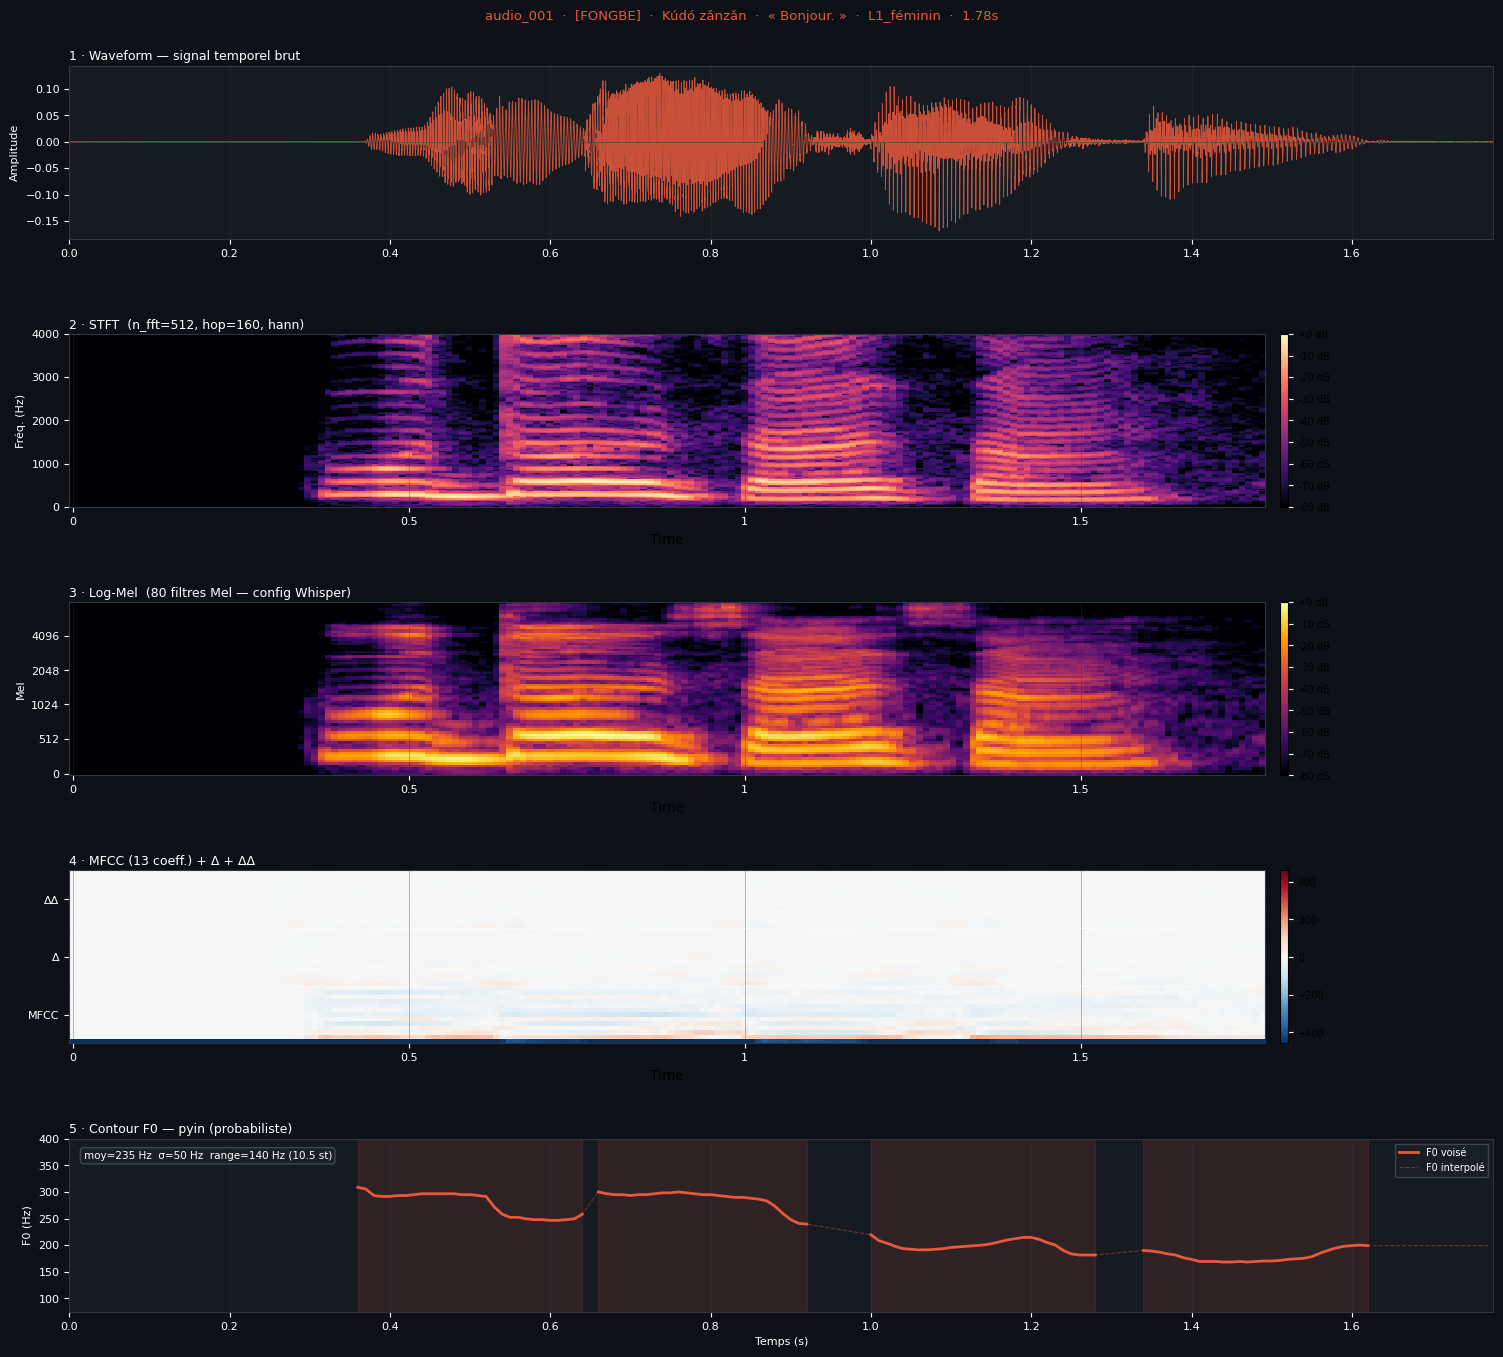


── WOLOF · wol_001 ──


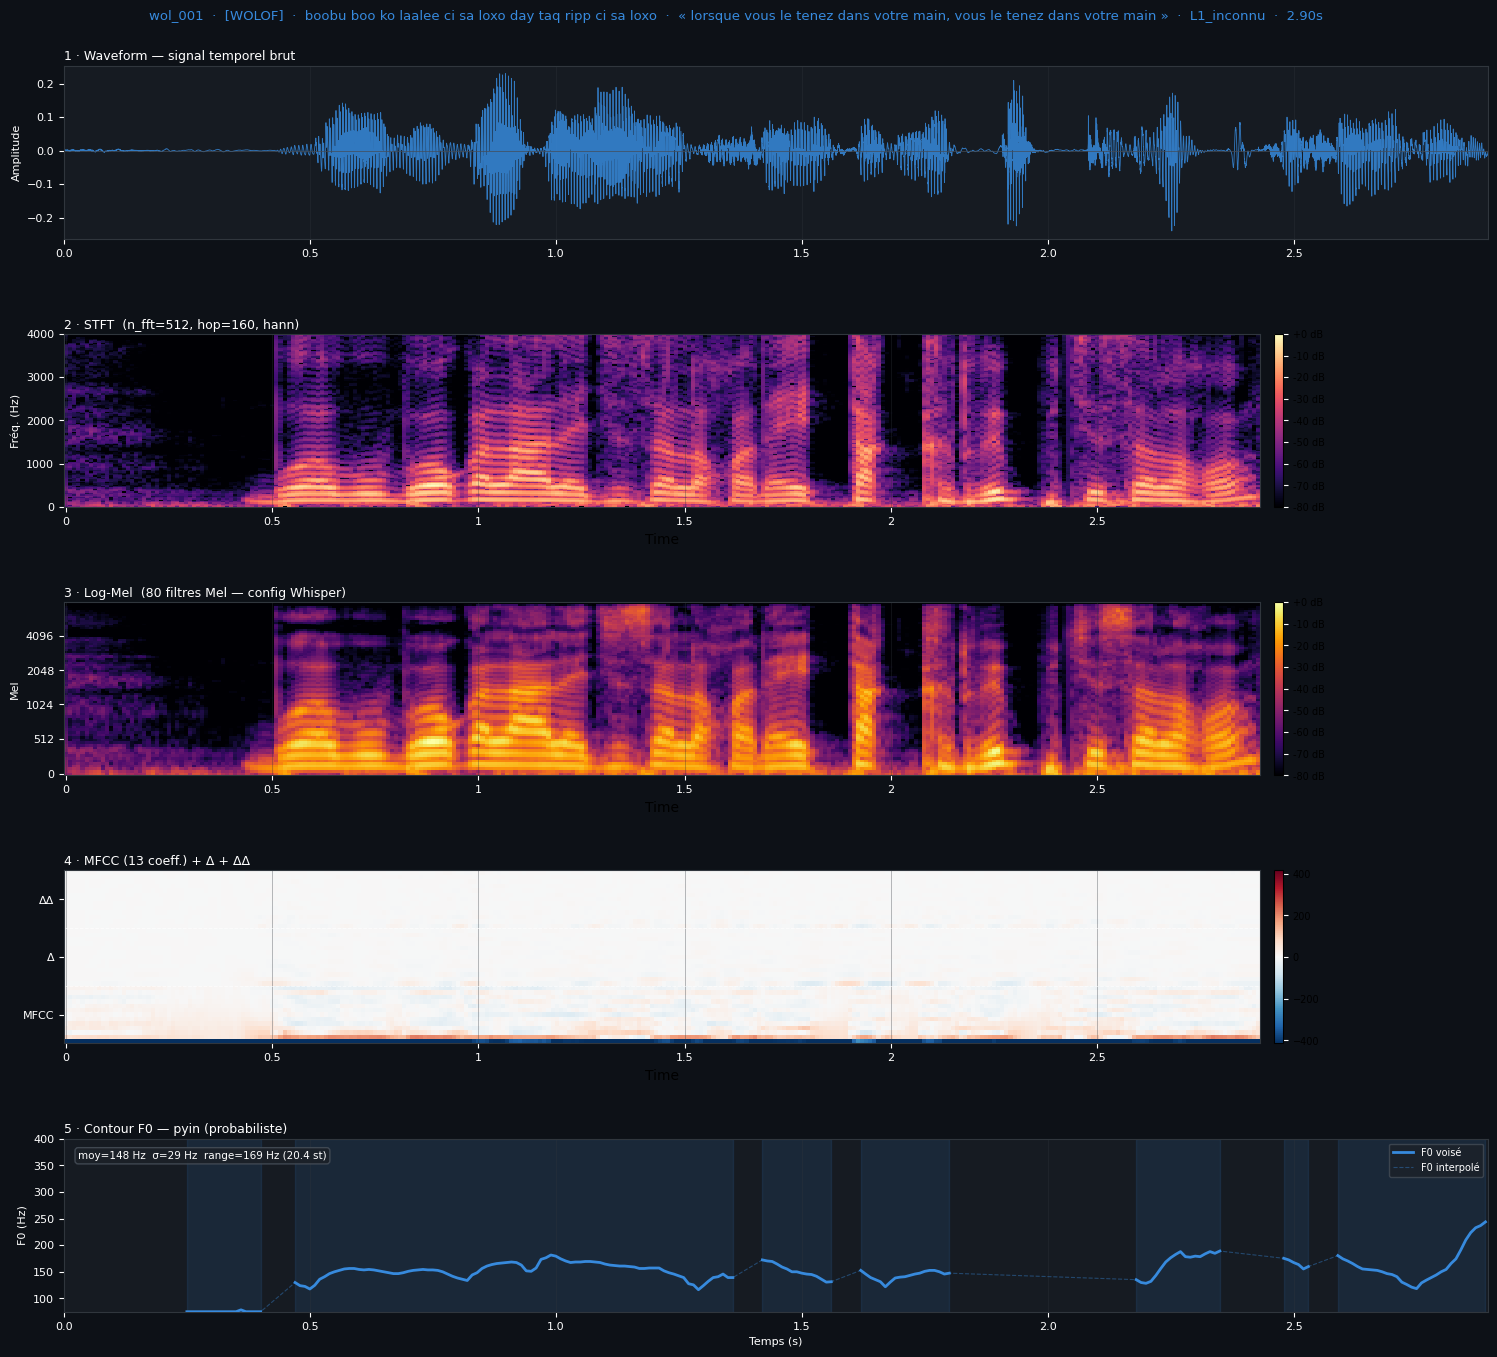


── SWAHILI · sw_001 ──


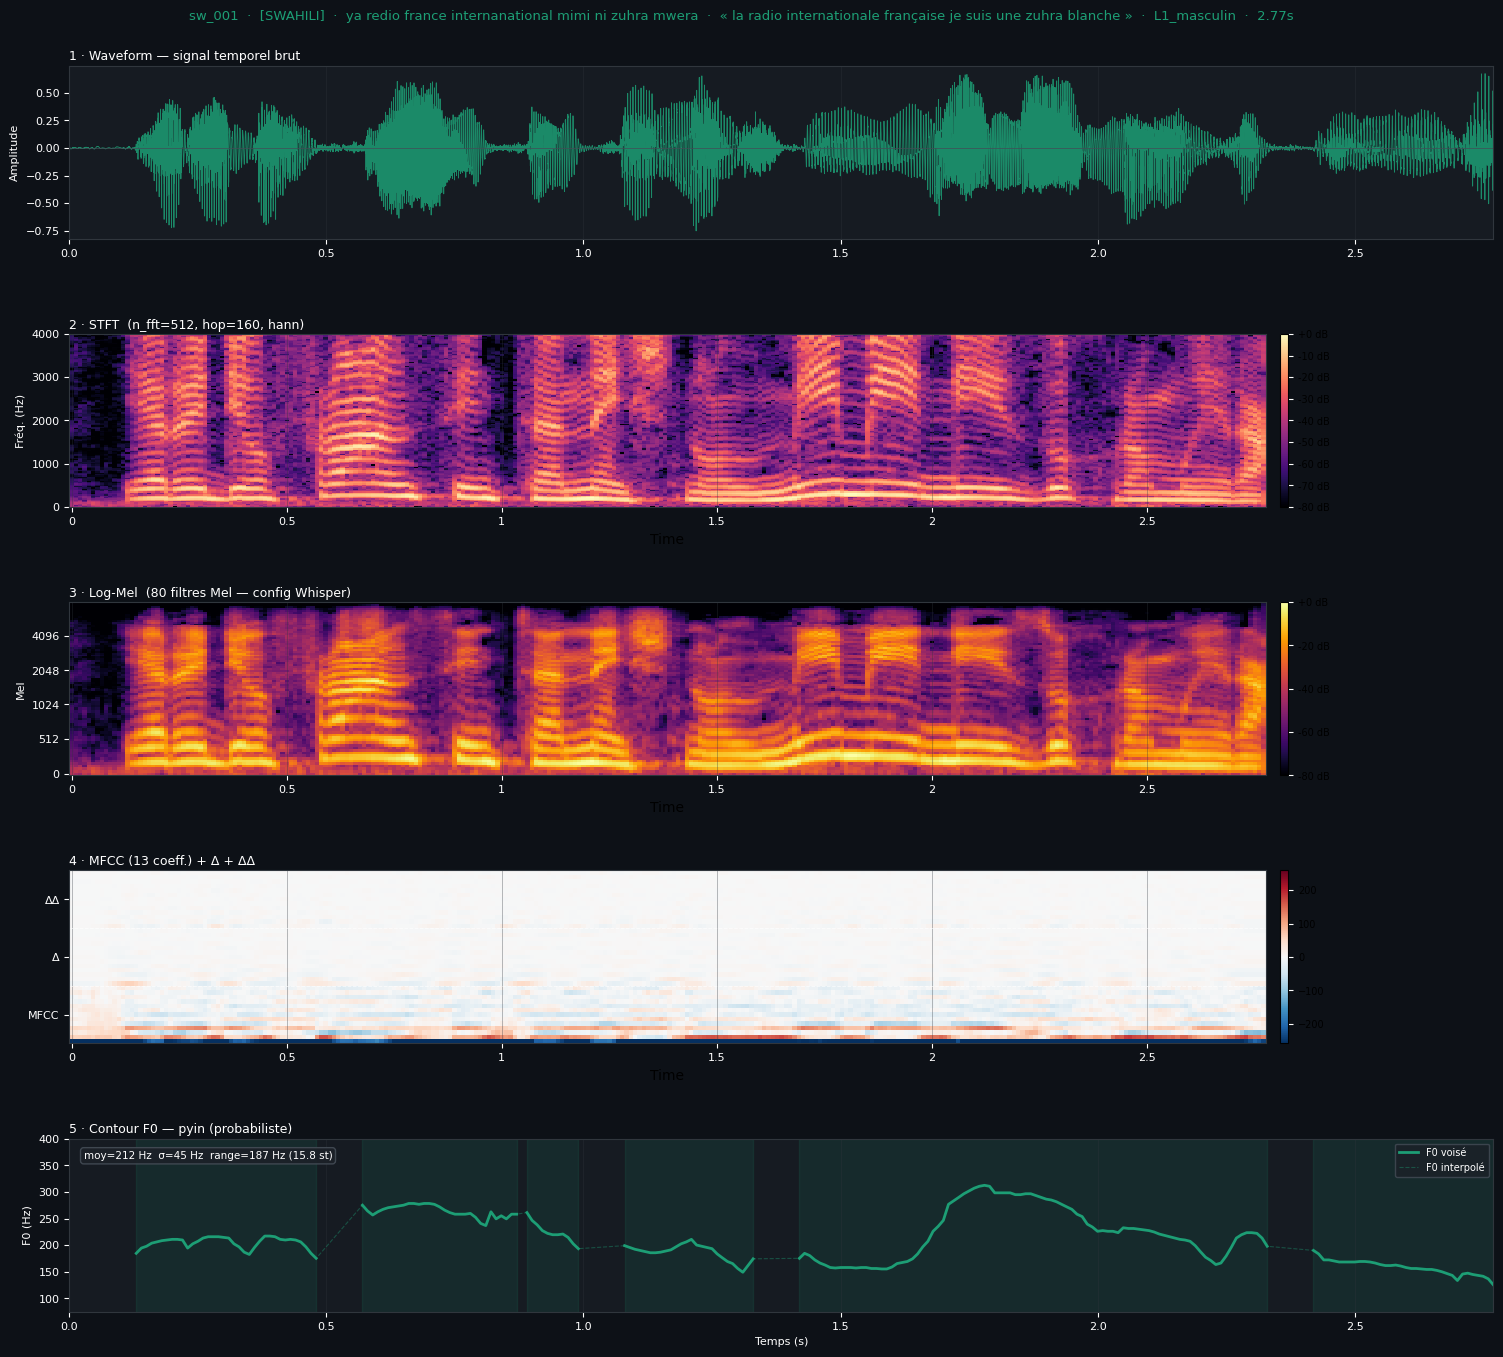

In [22]:
for langue in ['fongbe', 'wolof', 'swahili']:
    subset = df_corpus[df_corpus['langue'] == langue]
    if subset.empty:
        print(f'  Aucun énoncé pour {langue}')
        continue

    row  = subset.iloc[0].to_dict()
    path = resoudre_chemin(row)

    if path is None:
        print(f' Audio introuvable pour {langue} : {row["fichier_audio"]}')
        continue

    print(f'\n── {langue.upper()} · {row["id"]} ──')
    y, sr = charger_audio(path)
    tracer_planche(
        y, row,
        chemin_sortie=DOSSIER_PLAN / f'{row["id"]}_planche.png',
        afficher=True
    )

## 8. Fonctions d'annotation

In [23]:
def annoter(ax, texte, xy, xytext, couleur='white', taille=7.5):
    """
    Ajoute une annotation avec flèche sur un axe matplotlib.
    xy      : point cible de la flèche (coordonnées data)
    xytext  : position du texte (coordonnées data)
    """
    ax.annotate(
        texte,
        xy=xy, xytext=xytext,
        xycoords='data', textcoords='data',
        fontsize=taille, color=couleur,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#1C2128',
                  edgecolor=couleur, alpha=0.88, linewidth=0.8),
        arrowprops=dict(arrowstyle='->', color=couleur, lw=1.0,
                        connectionstyle='arc3,rad=0.15'),
        ha='left', va='center', zorder=10,
        path_effects=[pe.withStroke(linewidth=2, foreground='#0D1117')]
    )


def encadrer_zone(ax, x0, x1, y0, y1, couleur='#EF9F27', alpha=0.15, label=None):
    """
    Dessine un rectangle semi-transparent sur une zone d'intérêt.
    """
    rect = mpatches.FancyBboxPatch(
        (x0, y0), x1 - x0, y1 - y0,
        boxstyle='round,pad=0.02',
        linewidth=1.0, edgecolor=couleur,
        facecolor=couleur, alpha=alpha, zorder=5
    )
    ax.add_patch(rect)
    if label:
        ax.text((x0+x1)/2, y1, label, color=couleur, fontsize=7,
                ha='center', va='bottom', fontweight='bold', zorder=11,
                path_effects=[pe.withStroke(linewidth=2, foreground='#0D1117')])


print(' Fonctions d\'annotation définies')

 Fonctions d'annotation définies


## 9. Planches comparatives annotées — paires minimales fongbé

6 paire(s) minimale(s) détectée(s)

── pair_faudio_009 :  Nán vs  Ná
   Planche annotée → ../results/01_acoustic_analysis/planches_annotees/planche_annotee_pair_faudio_009.png


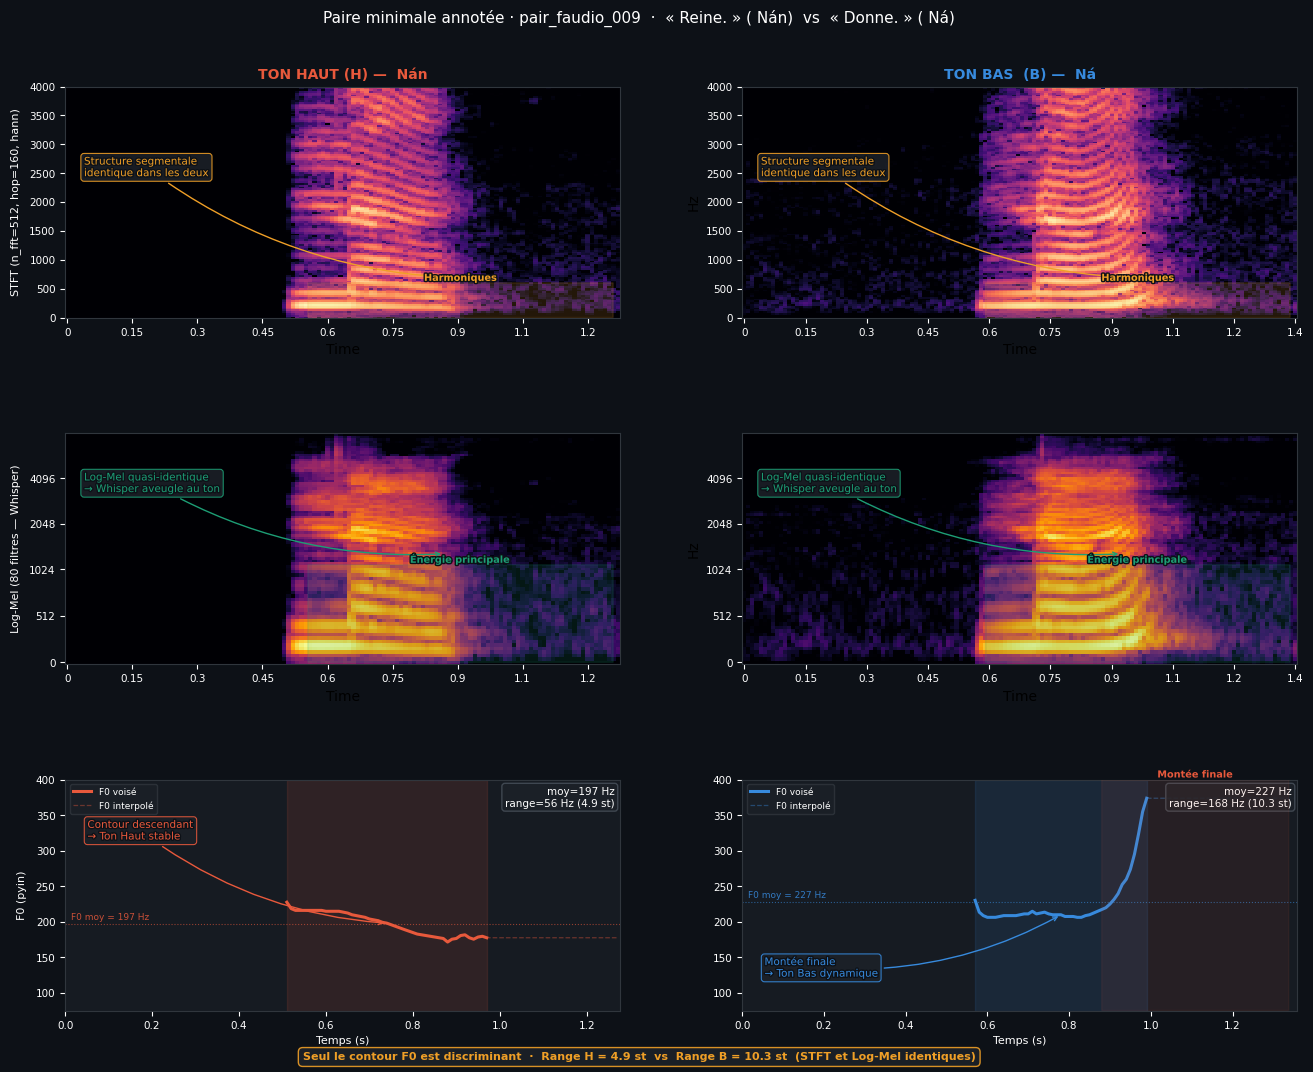

── pair_faudio_011 :  Àzɔ́n vs  Àzɔ̌
   Planche annotée → ../results/01_acoustic_analysis/planches_annotees/planche_annotee_pair_faudio_011.png


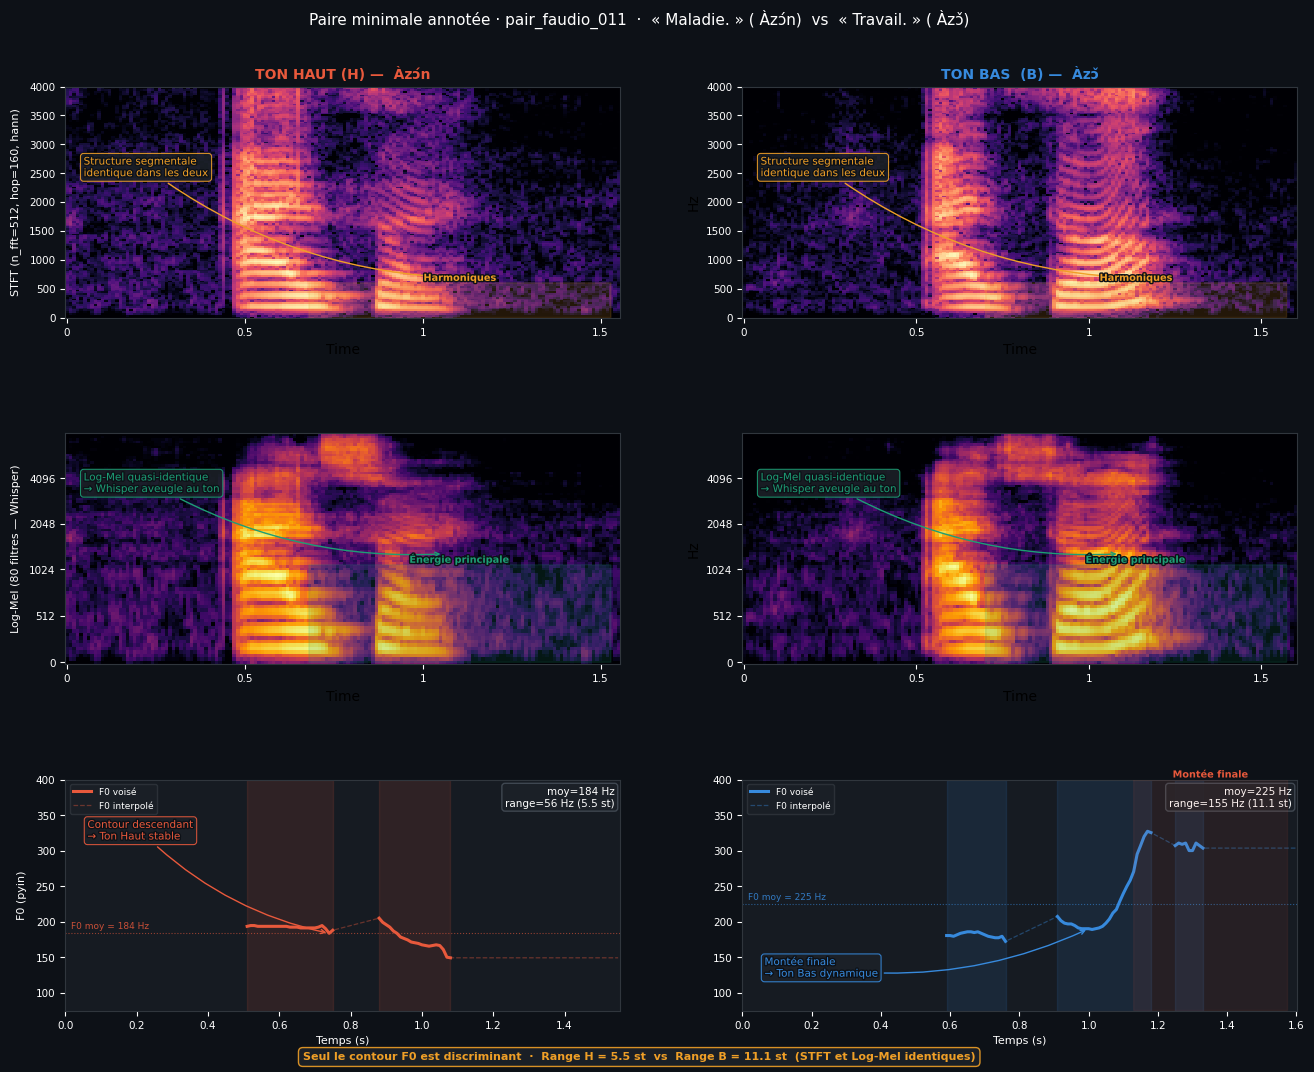

── pair_faudio_012 :  Asɔ́ vs  Àsɔ̀
   Planche annotée → ../results/01_acoustic_analysis/planches_annotees/planche_annotee_pair_faudio_012.png


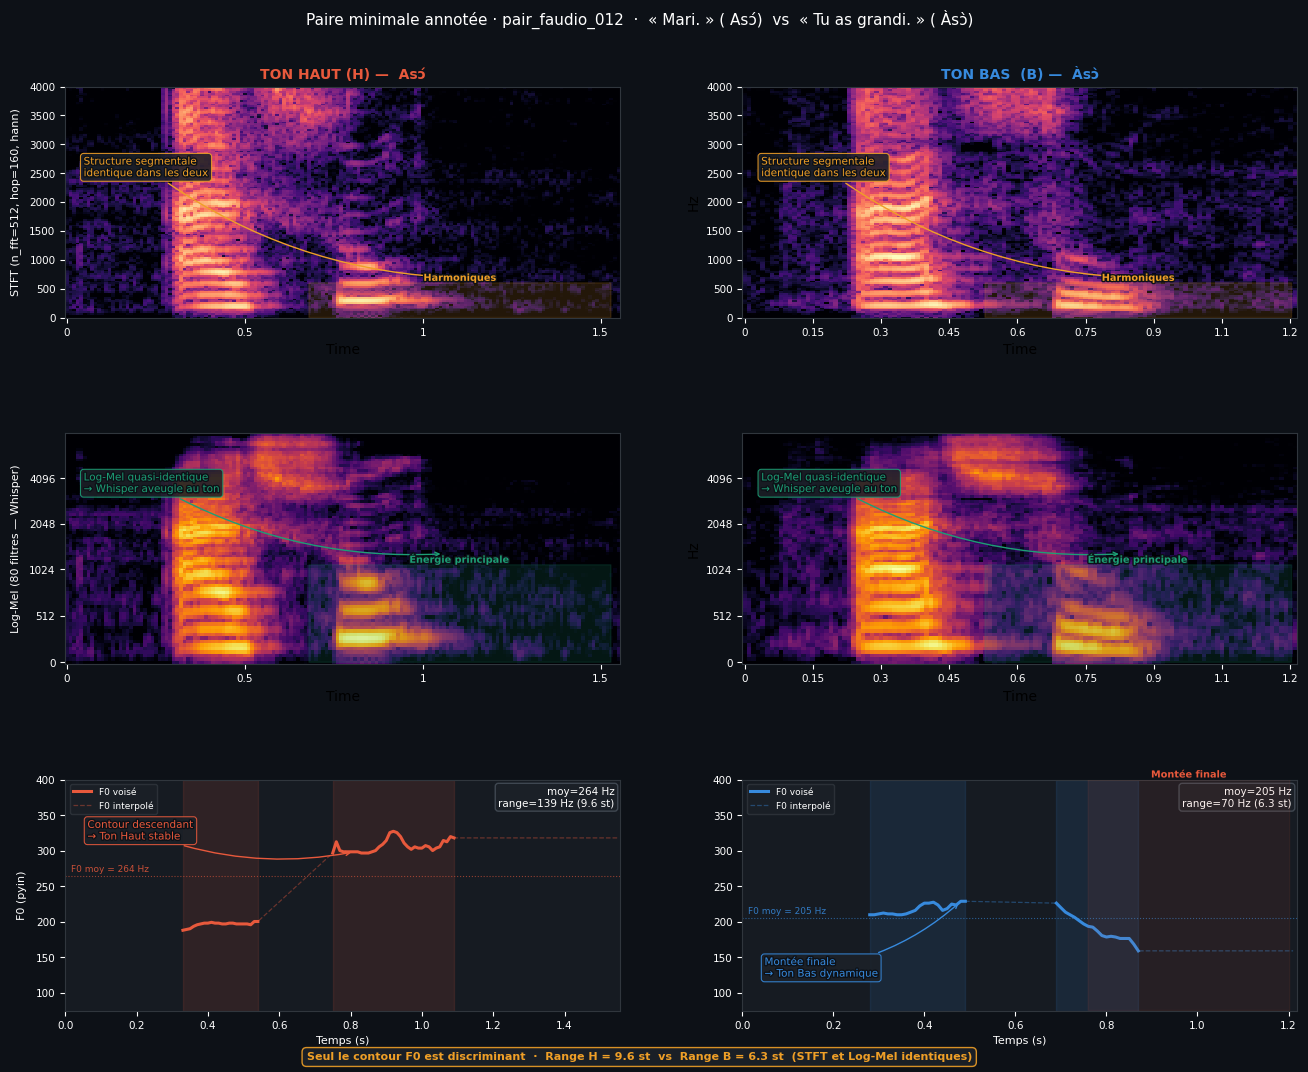

── pair_faudio_013 :  Tó vs  Tò
   Planche annotée → ../results/01_acoustic_analysis/planches_annotees/planche_annotee_pair_faudio_013.png


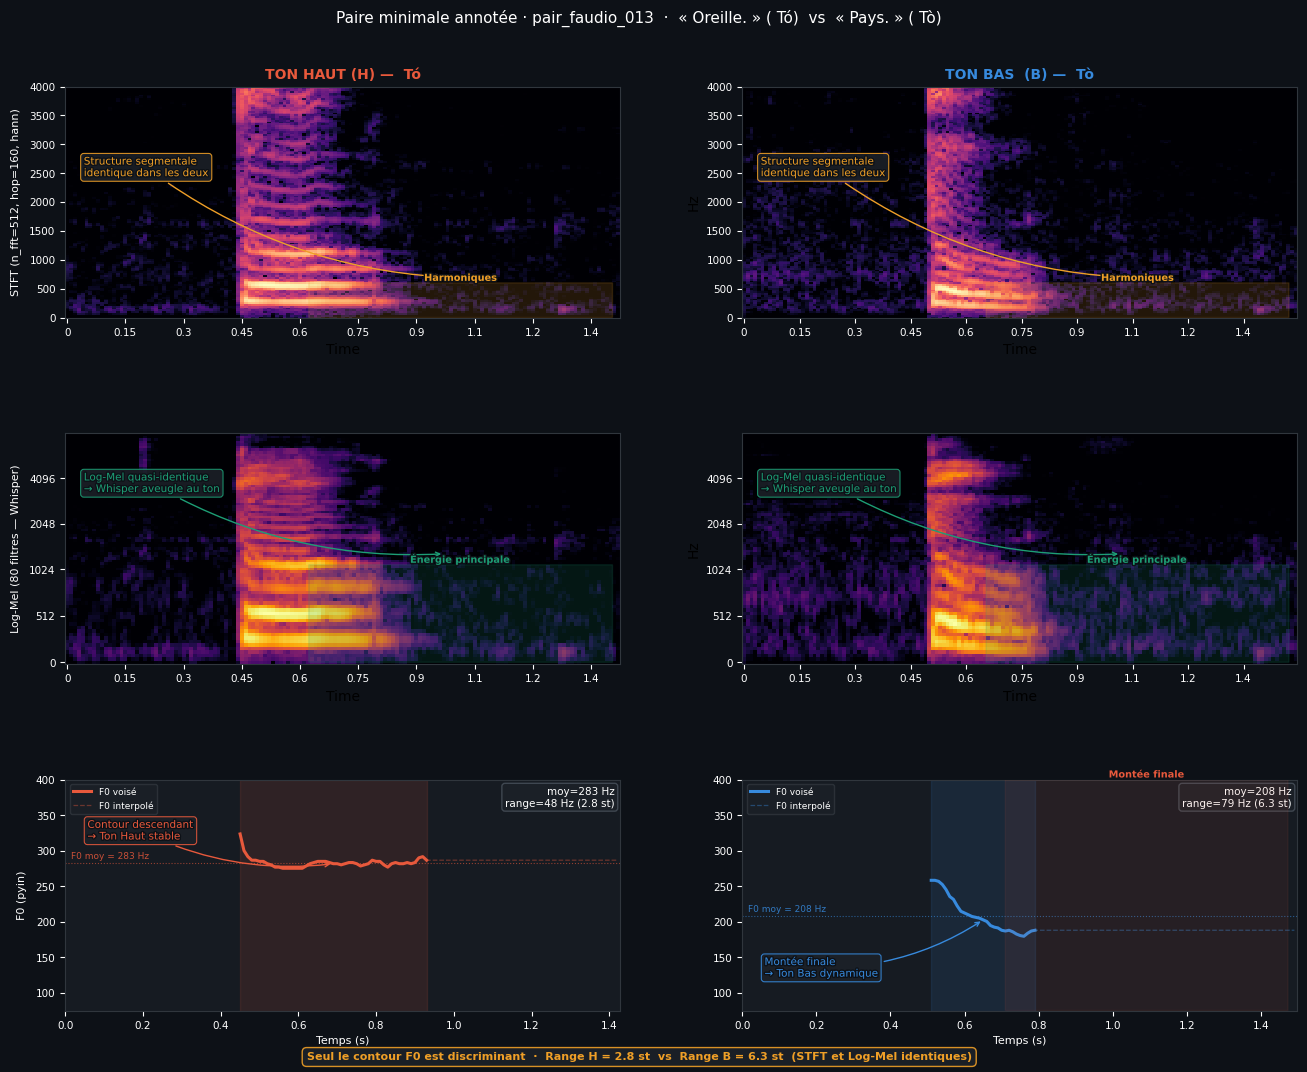

── pair_faudio_022 :  Yí vs  Yì
   Planche annotée → ../results/01_acoustic_analysis/planches_annotees/planche_annotee_pair_faudio_022.png


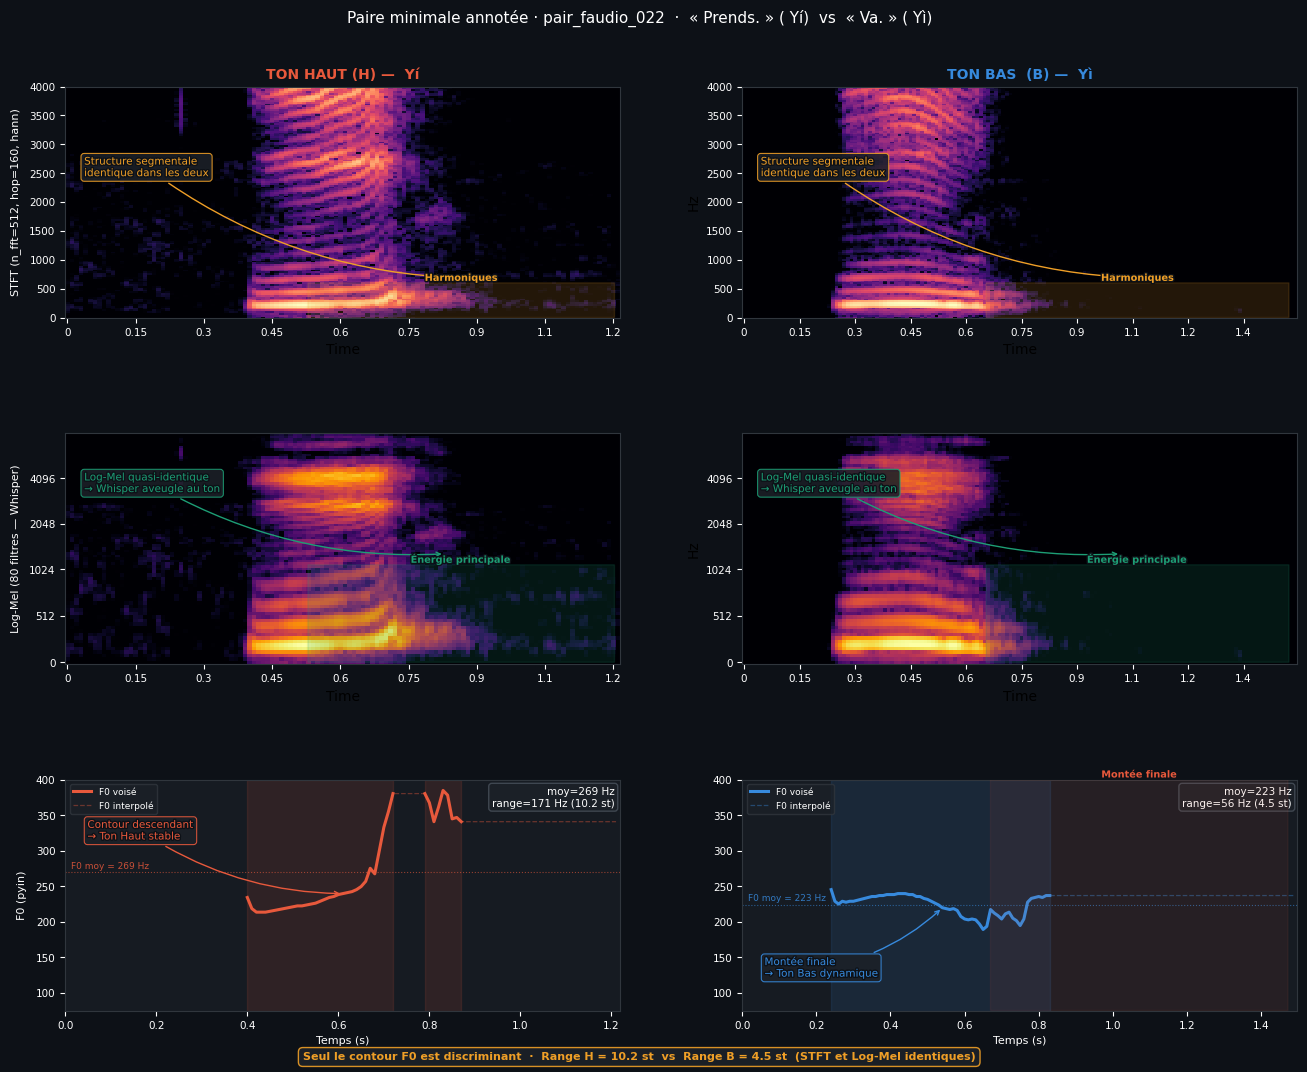

── pair_faudio_025 :  Kɔ́ vs  Kɔ̀
   Planche annotée → ../results/01_acoustic_analysis/planches_annotees/planche_annotee_pair_faudio_025.png


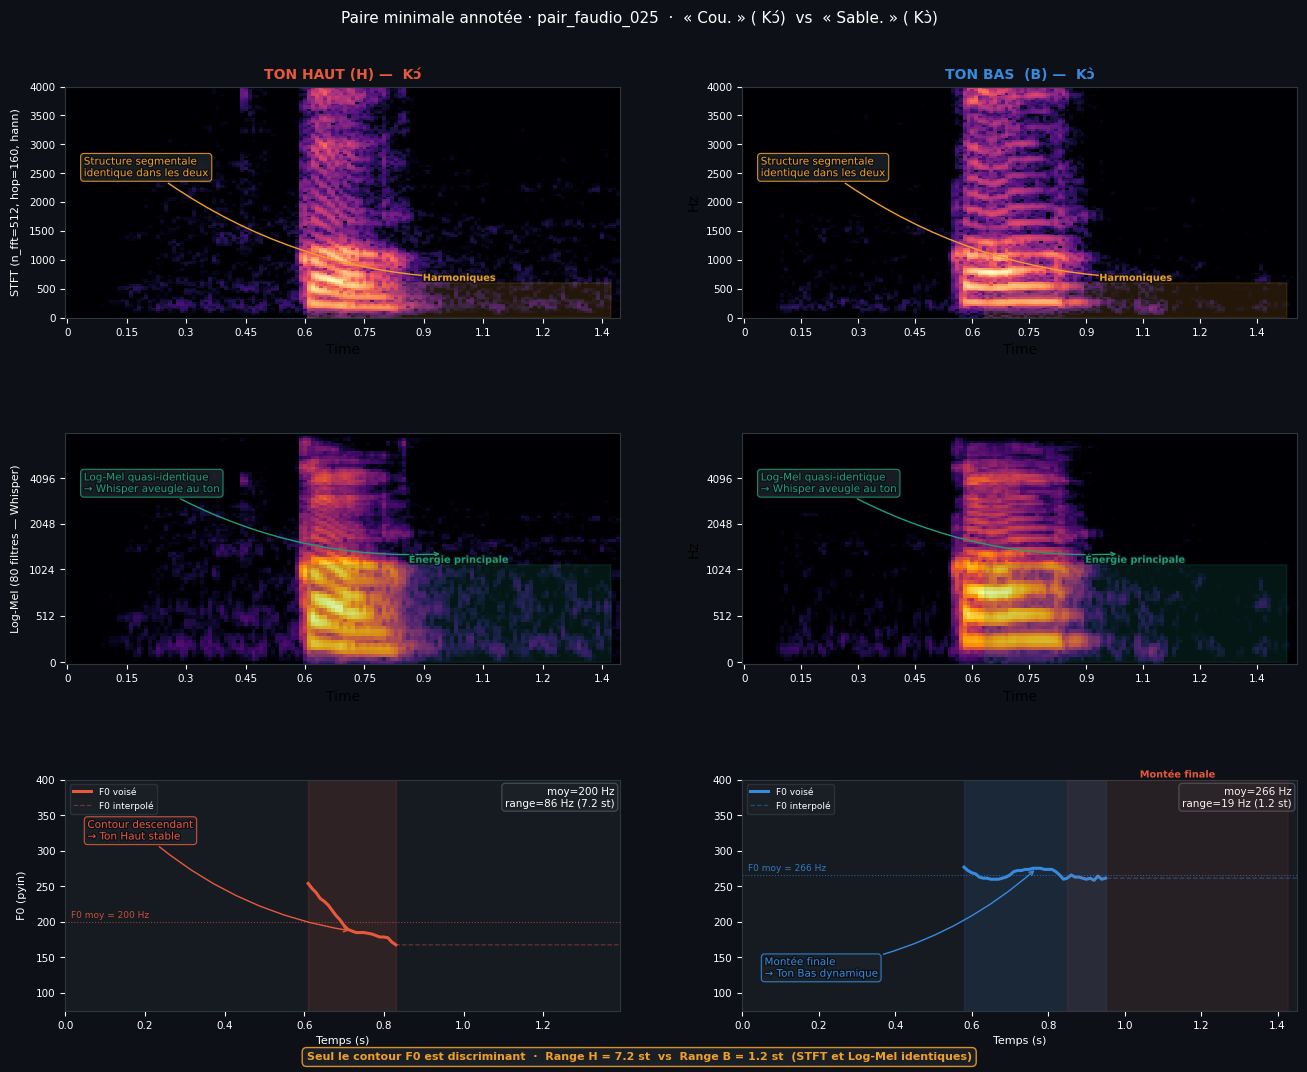

In [24]:
def tracer_paire_annotee(row_h, row_b, chemin_sortie=None, afficher=True):
    """
    Planche comparative ANNOTÉE côte à côte : Ton H (gauche) vs Ton B (droite).
    3 lignes : STFT | Log-Mel | F0
    Annotations : encadrés, flèches, textes sur les zones d'intérêt.
    """
    path_h = resoudre_chemin(row_h)
    path_b = resoudre_chemin(row_b)
    if path_h is None or path_b is None:
        print(f' Audio manquant pour la paire {row_h.get("id_paire","")}')
        return

    y_h, _ = charger_audio(path_h)
    y_b, _ = charger_audio(path_b)

    def _ext(y):
        D, _ = extraire_stft(y)
        M, _ = extraire_logmel(y)
        f0, v, t = extraire_f0(y)
        return D, M, f0, v, t

    D_h, M_h, f0_h, v_h, t_h = _ext(y_h)
    D_b, M_b, f0_b, v_b, t_b = _ext(y_b)
    sf_h = stats_f0(f0_h, v_h)
    sf_b = stats_f0(f0_b, v_b)
    dur_h = librosa.get_duration(y=y_h, sr=SR)
    dur_b = librosa.get_duration(y=y_b, sr=SR)

    pid    = row_h.get('id_paire', '')
    orth_h = row_h.get('transcription_ortho', '')
    orth_b = row_b.get('transcription_ortho', '')
    trad_h = row_h.get('traduction_fr', '')
    trad_b = row_b.get('traduction_fr', '')

    fig, axes = plt.subplots(3, 2, figsize=(14, 11))
    fig.patch.set_facecolor('#0D1117')
    plt.subplots_adjust(hspace=0.50, wspace=0.22,
                        top=0.91, bottom=0.07, left=0.09, right=0.97)

    fig.suptitle(
        f'Paire minimale annotée · {pid}  ·  '
        f'« {trad_h} » ({orth_h})  vs  « {trad_b} » ({orth_b})',
        color='white', fontsize=11, fontweight='medium'
    )

    cols_cfg = [
        (f'TON HAUT (H) — {orth_h}', '#E8593C',
         D_h, M_h, f0_h, v_h, t_h, dur_h, sf_h),
        (f'TON BAS  (B) — {orth_b}', '#378ADD',
         D_b, M_b, f0_b, v_b, t_b, dur_b, sf_b),
    ]

    def _style(ax):
        ax.set_facecolor('#161B22')
        ax.tick_params(colors='white', labelsize=7.5)
        for sp in ax.spines.values(): sp.set_edgecolor('#30363D')

    for c, (lbl, coul, D, M, f0, vd, tf, dur, sf) in enumerate(cols_cfg):
        axes[0, c].set_title(lbl, color=coul, fontsize=10, fontweight='bold', pad=6)

        # ── STFT ─────────────────────────────────────────────────────────────
        librosa.display.specshow(D, sr=SR, hop_length=HOP_LENGTH,
                                  x_axis='time', y_axis='hz',
                                  ax=axes[0, c], cmap='magma')
        axes[0, c].set_ylim(0, 4000)
        _style(axes[0, c])

        # Encadré jaune : zone harmoniques (basses fréquences)
        onset = dur * 0.45  # début de la zone voisée
        encadrer_zone(axes[0, c], onset, dur * 0.97,
                      0, 600, couleur='#EF9F27', alpha=0.15,
                      label='Harmoniques')

        # Flèche STFT → même structure segmentale
        annoter(axes[0, c],
                'Structure segmentale\nidentique dans les deux',
                xy=(dur * 0.68, 700),
                xytext=(dur * 0.03, 2600),
                couleur='#EF9F27')

        # ── LOG-MEL ───────────────────────────────────────────────────────────
        librosa.display.specshow(M, sr=SR, hop_length=HOP_LENGTH,
                                  x_axis='time', y_axis='mel',
                                  ax=axes[1, c], cmap='inferno')
        _style(axes[1, c])

        # Encadré vert : énergie principale basses fréquences
        encadrer_zone(axes[1, c], onset, dur * 0.97,
                      0, 1100, couleur='#1D9E75', alpha=0.15,
                      label='Énergie principale')

        # Flèche Log-Mel → Whisper aveugle au ton
        annoter(axes[1, c],
                'Log-Mel quasi-identique\n→ Whisper aveugle au ton',
                xy=(dur * 0.68, 1300),
                xytext=(dur * 0.03, 3800),
                couleur='#1D9E75')

        # ── F0 ────────────────────────────────────────────────────────────────
        axes[2, c].fill_between(tf, 0, F0_MAX, where=vd,
                                 alpha=0.12, color=coul)
        f0p = f0.copy(); f0p[~vd] = np.nan
        axes[2, c].plot(tf, f0p, color=coul, linewidth=2.2,
                         zorder=3, label='F0 voisé')
        f0i = pd.Series(f0).interpolate('linear').values
        axes[2, c].plot(tf, f0i, color=coul, linewidth=0.9,
                         alpha=0.4, linestyle='--', label='F0 interpolé')
        axes[2, c].set_ylim(F0_MIN, F0_MAX)
        axes[2, c].set_xlim(0, dur)
        axes[2, c].set_xlabel('Temps (s)', color='white', fontsize=8)
        axes[2, c].legend(fontsize=6.5, loc='upper left',
                           facecolor='#1C2128', edgecolor='#30363D',
                           labelcolor='white')
        _style(axes[2, c])

        # Ligne pointillée F0 moyenne
        f0_moy = sf.get('f0_mean', 0) or 0
        axes[2, c].axhline(f0_moy, color=coul, linewidth=0.8,
                            linestyle=':', alpha=0.6)
        axes[2, c].text(dur * 0.01, f0_moy + 6,
                         f'F0 moy = {f0_moy:.0f} Hz',
                         color=coul, fontsize=6.5, alpha=0.85)

        # Stats F0
        rng_hz = sf.get('f0_range_hz', 0) or 0
        rng_st = sf.get('f0_range_st', 0) or 0
        axes[2, c].text(
            0.99, 0.97,
            f'moy={f0_moy:.0f} Hz\nrange={rng_hz:.0f} Hz ({rng_st:.1f} st)',
            transform=axes[2, c].transAxes, color='white',
            fontsize=7.5, va='top', ha='right',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#1C2128',
                      edgecolor='#444C56', alpha=0.9)
        )

        # Flèche F0 : contour descendant (H) ou montant (B)
        idx_vd = np.where(vd & ~np.isnan(f0))[0]
        if len(idx_vd) > 5:
            mid = idx_vd[len(idx_vd) // 2]
            ax_x = float(tf[mid])
            ax_y = float(f0[mid])
            txt_y = F0_MAX * 0.82 if c == 0 else F0_MIN * 1.8
            desc  = 'Contour descendant\n→ Ton Haut stable' if c == 0 \
                    else 'Montée finale\n→ Ton Bas dynamique'
            annoter(axes[2, c], desc,
                    xy=(ax_x, ax_y),
                    xytext=(dur * 0.04, txt_y),
                    couleur=coul)

        # Encadré rouge sur la montée finale du Ton B
        if c == 1 and len(idx_vd) > 3:
            dernier = idx_vd[-max(1, len(idx_vd)//4):]
            t_debut = float(tf[dernier[0]])
            encadrer_zone(axes[2, c], t_debut, dur * 0.97,
                          F0_MIN, F0_MAX, couleur='#E8593C', alpha=0.08,
                          label='Montée finale')

    # Labels lignes
    for r, lbl in enumerate([
        f'STFT (n_fft={N_FFT}, hop={HOP_LENGTH}, {WINDOW})',
        f'Log-Mel ({N_MELS} filtres — Whisper)',
        'F0 (pyin)'
    ]):
        axes[r, 0].set_ylabel(lbl, color='white', fontsize=8,
                               fontweight='medium', labelpad=6)

    # Bandeau comparatif range F0
    rng_h = sf_h.get('f0_range_st', 0) or 0
    rng_b = sf_b.get('f0_range_st', 0) or 0
    fig.text(
        0.5, 0.025,
        f'Seul le contour F0 est discriminant  ·  '
        f'Range H = {rng_h:.1f} st  vs  Range B = {rng_b:.1f} st  '
        f'(STFT et Log-Mel identiques)',
        color='#EF9F27', fontsize=8, ha='center', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#1C2128',
                  edgecolor='#EF9F27', alpha=0.9)
    )

    if chemin_sortie:
        Path(chemin_sortie).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(str(chemin_sortie), facecolor='#0D1117',
                    bbox_inches='tight', dpi=180)
        print(f'   Planche annotée → {chemin_sortie}')
    if afficher:
        plt.show()
    else:
        plt.close(fig)


# ── Générer toutes les planches annotées ──────────────────────────────────────
paires_df = df_corpus[df_corpus['paire_minimale'] == 'oui']

if paires_df.empty:
    print('  Aucune paire minimale dans metadata.csv')
    print('   → Configurer paire_minimale=oui et id_paire dans le CSV')
else:
    nb_paires = paires_df['id_paire'].nunique()
    print(f'{nb_paires} paire(s) minimale(s) détectée(s)\n')

    for pid, grp in paires_df.groupby('id_paire'):
        if len(grp) != 2:
            print(f'  {pid} : {len(grp)} membre(s) — attendu 2')
            continue
        grp_s = grp.sort_values(
            'ton_patron',
            key=lambda x: x.map({'H': 0, 'B': 1}).fillna(2)
        )
        row_h = grp_s.iloc[0].to_dict()
        row_b = grp_s.iloc[1].to_dict()
        print(f'── {pid} : {row_h.get("transcription_ortho","?")} '
              f'vs {row_b.get("transcription_ortho","?")}')
        tracer_paire_annotee(
            row_h, row_b,
            chemin_sortie=DOSSIER_PLAN_ANN / f'planche_annotee_{pid}.png',
            afficher=True
        )

## 10. Pipeline complet — tout le corpus (100 énoncés)

In [25]:
rows_features = []
erreurs       = []
total         = len(df_corpus)

print(f'Pipeline complet — {total} énoncés\n')

for i, row in df_corpus.iterrows():
    meta = row.to_dict()
    eid  = meta.get('id', f'unk_{i}')
    lang = meta.get('langue', '')

    path = resoudre_chemin(meta)
    if path is None:
        erreurs.append(eid)
        print(f'  [{i+1:>3}/{total}]   {eid}  — audio introuvable')
        continue

    print(f'  [{i+1:>3}/{total}] {eid:<12} [{lang}]  '
          f'{meta.get("transcription_ortho","")[:35]}')

    y, sr = charger_audio(path)

    # Planche individuelle (afficher=False pour aller vite)
    tracer_planche(
        y, meta,
        chemin_sortie=DOSSIER_PLAN / f'{eid}_planche.png',
        afficher=False
    )

    # Features pour SVM Phase 2
    mfcc_d     = extraire_mfcc(y)
    f0, vd, _  = extraire_f0(y)
    rows_features.append({
        'id':             eid,
        'langue':         lang,
        'locuteur':       meta.get('locuteur',''),
        'ton_patron':     meta.get('ton_patron',''),
        'paire_minimale': meta.get('paire_minimale','non'),
        'id_paire':       meta.get('id_paire',''),
        'duree_sec':      round(librosa.get_duration(y=y, sr=SR), 3),
        **stats_f0(f0, vd),
        **stats_mfcc(mfcc_d),
    })

# Export features
df_feat = pd.DataFrame(rows_features)
df_feat.to_csv(CSV_FEATURES, index=False, encoding='utf-8-sig')

print(f'\n{"═"*55}')
print(f'    {len(rows_features)} énoncés traités')
if erreurs:
    print(f'    {len(erreurs)} audios introuvables : {erreurs}')
print(f'   Planches   → {DOSSIER_PLAN}/')
print(f'   Features   → {CSV_FEATURES}')
print(f'{"═"*55}')

Pipeline complet — 100 énoncés

  [  1/100] wol_001      [wolof]  boobu boo ko laalee ci sa loxo day 
  [  2/100] wol_002      [wolof]  Station shell icotaf
  [  3/100] wol_003      [wolof]  ba mu egsee ñépp wër ko mu ni leen
  [  4/100] wol_004      [wolof]  budee lu mel ni que business en pla
  [  5/100] wol_005      [wolof]  amoon na ñu daan gas di ci denc see
  [  6/100] wol_006      [wolof]  dañuy dem ba mois aôut bi jeex nga 
  [  7/100] wol_007      [wolof]  toN toN u naat saa yu wëree am réew
  [  8/100] wol_008      [wolof]  bañ loo menul à vañi darà moo k beg
  [  9/100] wol_009      [wolof]  Le Baol
  [ 10/100] wol_010      [wolof]  damay wax ni ñëpp d ici 2080 dem 30
  [ 11/100] wol_011      [wolof]  mu ne du la may doomam ndax géwal n
  [ 12/100] wol_012      [wolof]  su fekkee ne mu nga fa dinaa ko ko 
  [ 13/100] wol_013      [wolof]  parce que boo parcourir ree 1 kilom
  [ 14/100] wol_014      [wolof]  sedd lañu nekk guddi gi dafay teel 
  [ 15/100] wol_015      [wolof]

## 11. Aperçu des features extraites

In [51]:
df_feat = pd.read_csv(CSV_FEATURES, encoding='utf-8-sig')

print(f'Features extraites : {len(df_feat)} énoncés × {len(df_feat.columns)} colonnes\n')

# Statistiques F0 moyennes par langue
cols_f0 = ['f0_mean','f0_std','f0_range_hz','f0_range_st',
           'n_inflexions_per_sec','voiced_ratio']
print('Statistiques F0 par langue :')
print(df_feat.groupby('langue')[cols_f0].mean().round(2).to_string())

print('\nAperçu des 5 premières lignes :')
df_feat[['id','langue','duree_sec','f0_mean','f0_std',
          'f0_range_hz','mfcc_01_mean','mfcc_02_mean']].head()

Features extraites : 100 énoncés × 29 colonnes

Statistiques F0 par langue :
         f0_mean  f0_std  f0_range_hz  f0_range_st  n_inflexions_per_sec  voiced_ratio
langue                                                                                
fongbe    231.83   39.26       140.51         9.95                  9.06          0.51
swahili   187.64   26.56       129.73        12.15                 16.16          0.78
wolof     157.99   26.73       114.29        12.01                 11.70          0.44

Aperçu des 5 premières lignes :


,id,langue,duree_sec,f0_mean,f0_std,f0_range_hz,mfcc_01_mean,mfcc_02_mean
0,wol_001,wolof,2.895,148.30,29.37,168.68,-531.5978,119.2184
1,wol_002,wolof,2.664,261.25,45.87,129.97,-451.7088,36.8061
2,wol_003,wolof,5.273,198.27,55.29,218.15,-464.9647,109.3173
3,wol_004,wolof,8.999,137.06,20.13,102.96,-415.2379,94.9716
4,wol_005,wolof,5.220,116.90,8.17,48.96,-463.6488,91.1642
